# Let's code up a Hopfeild network and store some patterns in it!

In [1]:
from IPython.display import HTML
from numpy import fft
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation
from scipy.spatial.distance import hamming

from utils import *

# Archeteture of a Hopfeild Network

Hopfeild networks are fully conected (each neuron is connected to every other neuron), reccurent (outputs get passed back into the network as inputs in the next iteration) neural networks. Hopfeild network weight/connection matricies are formed by summing the outter product matricies of all stored patterns.

Given a number of N-dimensional patterns $ x^s $ with values of [-1,1], the NxN weight matrix $ W $ is formed as follows:

## $ W = \sum_s{x^s x^{sT}} \quad ;  \quad  W_{ii} = 0 $

OR

## $ W_{ij} = \sum_s{x_i^s x_j^s} \quad ;  \quad  W_{ii} = 0 $

The given an input vector $ y $, the network is updated according to:

## $ y(t+1) = sign(W y(t)) $

# What is a Hopfeild network? 

Why do you form the weight matrix as the outter product of stored pattern vectors? How does taking the inner product of the input pattern with the weight matrix recover the closest stored pattern?

Let's explore these questions with a simple weight matrix containing a single pattern below. Here we form a sample N-dimensional pattern a and calculate its coresponding weight matrix w:

In [ ]:
N = 5
a = np.random.choice([-1,1], size=5)
print('stored pattern: ', a, '\n')
w = np.outer(a, a)
np.fill_diagonal(w, 0)
print('Weight matrix for stored pattern:')
print(w)

stored pattern:  [ 1 -1 -1 -1  1] 

Weight matrix for stored pattern:
[[ 0 -1 -1 -1  1]
 [-1  0  1  1 -1]
 [-1  1  0  1 -1]
 [-1  1  1  0 -1]
 [ 1 -1 -1 -1  0]]


Here we randomly generate a N-dimensional input vector $i$ and pass it through our Hopfeild network with connectivity matrix $ W $ until it stops changing: 

In [46]:
i = np.zeros(N)
i_nxt = np.random.choice([-1,1], size=5)
print('iteration 0: ', i_nxt)
j = 0
while not np.array_equal(i,i_nxt):
    j += 1
    i = i_nxt
    i_nxt = np.sign(w @ i)
    print(f'iteration {j}: ', i_nxt)

iteration 0:  [-1 -1 -1  1  1]
iteration 1:  [ 1  0  0 -1  0]
iteration 2:  [ 1 -1 -1 -1  1]
iteration 3:  [ 1 -1 -1 -1  1]


## Hopfeild Networks for Pattern Completion/Recognition

Here we will create a Hopfeild network with one node for each pixel of the input patterns we will store in it so with an nxm pixel image we will have M=nxm nodes in our network.

In [16]:
patterns = np.load("hopfield_patterns.npy")
patterns = np.transpose(patterns.T.reshape(3, 10, 10), (0, 2, 1))

N = patterns.shape[0]
sz = patterns.shape[1]
M = sz**2

print(f"Dimension of patterns to be stored:\t{patterns.shape[1]}x{patterns.shape[2]}")
print(f"Numer of nodes in Hopfeild network:\t{M}")

Dimension of patterns to be stored:	10x10
Numer of nodes in Hopfeild network:	100


Here are the patterns we will store in our network:

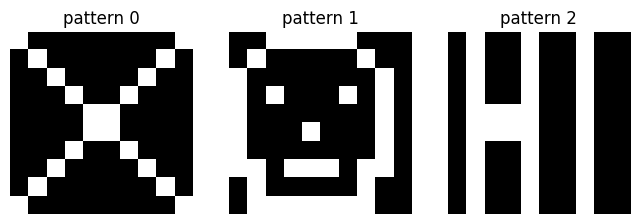

In [3]:
fig, axes = plt.subplots(1, patterns.shape[0])
fig.set_size_inches(8, 4)
for i in range(patterns.shape[0]):
    axes[i].imshow(patterns[i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"pattern {i}")

## Learning weights for a Hopfeild Network

Weights determine the connection strength between each node in our network. As each node in the network is connected to all other nodes, if we have M noddes, we will have an MxM weight matrix ($M^2$ weights).

To store a pattern in our network, we encode it into the weight matrix of the network. To do this, we take the outter product of our flattened pattern to form the weight matrix for that pattern. Pattern values are in the range [-1,1] so creating a weight matrix from the outter product of a given pattern ensures that that same pattern will have the highest inner product with the weight matrix. 

In [4]:
def init_weights(patterns):
    """Given patterns (num_patterns, height, width), returns weights
    (num_neurons, num_neurons).
    """
    N = patterns.shape[0]
    num_neurons = patterns.shape[1] * patterns.shape[2]
    weights = np.zeros((num_neurons, num_neurons))
    for i in range(N):
        # store this pattern in the weight matrix
        weights += np.outer(patterns[i].flatten(), patterns[i].flatten())
    np.fill_diagonal(weights, 0)
    return weights


## Recovering stored patterns

The computation preformed by Hopfeild networks is a matrix multiplication of the 1xM input vector over the MxM weight matrix, resulting in a 1xM inner product vector which is also decodeable as a pattern. 

With these dynamics, the patterns stored in the network which are most similar (pixel-wise) to the input will be amplified while those that are less similar will be diminished.

In [5]:
def recall(input, weights, m, iters=1, seed=0):
    """Performs recall.

    Args:
    input: (num_neurons, num_neurons).
    weights: (num_neurons, num_neurons).
    m: number of nodes in the network
    iters: number of iterations to update the full set of neurons.

    Returns:
    states: (num_neurons, num_neurons).
    all_states: (num_steps, num_neurons, num_neurons).
    iters: number of iterations to update the full set of neurons. In this
        implementation, it generally converges in just one iteration.
    seed: random seed.
    """
    states = input.flatten()
    rng = np.random.default_rng(seed)

    all_states = []
    for _ in range(iters):
        # Perform asynchronous updates for every neuron, but in random order. There
        # are many other ways to select the update order.
        for i in rng.permutation(range(m)):
            # to calculate a single element of the output vector at each iteration, we take the inner product between the current state and row of the weight matrix at the same index (produces a scalar)
            # we round the result to either -1 or 1
            states[i] = int(np.sign(np.inner(states, weights[i])))
            all_states.append(np.copy(states))

    all_states = np.reshape(np.asarray(all_states), (-1, int(np.sqrt(m)), int(np.sqrt(m))))

    return states, all_states

## Running the Hopfeild network

Once we have stored our input patterns in the Hopfeild network, the network can take any pattern as input and will return the closest stored pattern. 

Let's test this by adding noise to our input patterns and passing them into the network!

MovieWriter ffmpeg unavailable; using Pillow instead.


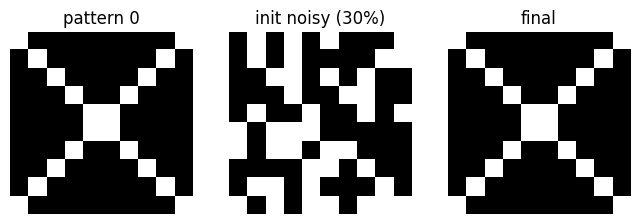

MovieWriter ffmpeg unavailable; using Pillow instead.


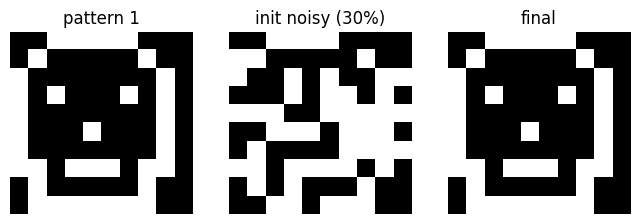

MovieWriter ffmpeg unavailable; using Pillow instead.


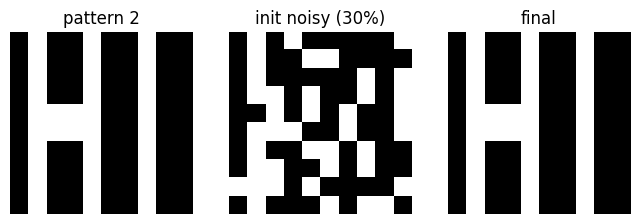

In [9]:
# Init weights given patterns.
weights = init_weights(patterns)
rng = np.random.default_rng(0)
noisy_frac = 0.3    # try playing around with this yourself!

for i, pattern in enumerate(patterns):
    # Create an initial input by adding a noise to the second original pattern.
    noisy = np.copy(pattern.reshape((1, M)))
    idx = rng.choice(np.arange(0, M), int(M*noisy_frac), replace=False)
    noisy[:, idx] *= -1  # flip value

    # pass the noisy patterns through the network
    final, all_states = recall(noisy, weights, M, iters=1)

    # Plot animation.
    fig, ax = plt.subplots()
    fig.set_size_inches(3, 3)
    plt.axis("off")
    im = ax.imshow(all_states[0], cmap="gray")

    def _updatefig(frame):
        ax.cla()
        plt.axis("off")
        im = ax.imshow(all_states[frame], cmap="gray")
        ax.set_title("step {}".format(frame))
        return (im, )
    
    anim = animation.FuncAnimation(fig, _updatefig, interval=20, frames=len(all_states), blit=True)
    anim.save(f'hop{i}.gif', fps=15)
    html = HTML(anim.to_jshtml())
    display(html)
    plt.close()

    # Plot target pattern, noisy pattern, and final recalled pattern.
    fig, axes = plt.subplots(1, 3)
    fig.set_size_inches(8, 4)
    axes[0].imshow(pattern.reshape(sz, sz), cmap="gray")
    axes[0].axis("off")
    axes[0].set_title(f"pattern {i}")

    axes[1].imshow(noisy.reshape(sz, sz), cmap="gray")
    axes[1].axis("off")
    axes[1].set_title(f"init noisy ({int(noisy_frac*100)}%)")

    axes[2].imshow(final.reshape(sz, sz), cmap="gray")
    axes[2].axis("off")
    axes[2].set_title("final")
    plt.show()

Try playing around with the amout of noise added to the input patterns (noisy_frac variable defined on line 4 above). At what point does the network loose the ability to recover the stored pattern? Is this supprising?

# Exploring the capacity of Hopfeild networks

Given the way patterns are stored in the weight matrix, there becomes a point at which averaging more patterns into the wieghts degrades them to the point that no individual pattern is recoverable. The capacity of a network describes how many patterns it can store and still faithfully recover. As you store more patterns than a network has the capacity to handle, the error in recall increases.

Let's explore this by storing an increasing number of patterns in the network and recoding the recall error at each stage.

In [29]:
def get_frac_error(data, num_recalls=30):
    """Get the average fraction of errors made across all recall attempts for
    this dataset, where error is indicated by hamming distance > 0.

    Args:
    data: (num_patterns, height, width)
    num_recalls: number of recall attempts.

    Returns:
    Average number of errors made across all recall attempts.
    """
    weights = init_weights(data)
    hammings = []
    for i in range(num_recalls):
        # For each recall attempt, set a different seed so that the order of state
        # updates is different.
        rng = np.random.default_rng(i)
        # Select a random initial pattern from the stored patterns.
        data_idx = rng.choice(np.arange(0, data.shape[0]))
        final, _ = recall(data[data_idx], weights, M, seed=i)
        # Calulate hamming distance between initial pattern and final pattern.
        hammings.append(hamming(data[data_idx].flatten(), final.flatten()))

    # If hamming distance is greater than 0, there was an error. Return the
    # average number of errors made over all recall attempts.
    return np.mean((np.array(hammings) > 0) * 1)

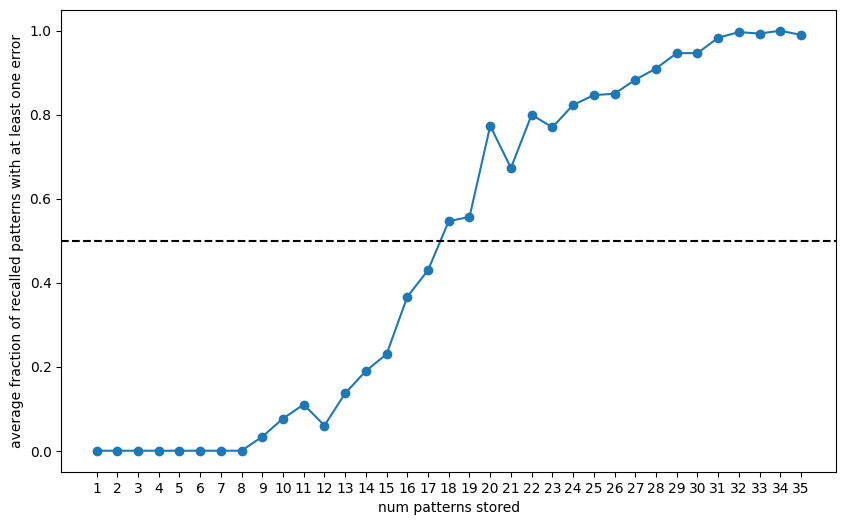

In [ ]:
max_patterns = 35
num_trials = 10
all_errs = []
for t in range(num_trials):
    errs = []
    # Each trial, change the seed so all patterns and updates are different.
    rng = np.random.default_rng(t)
    for i in range(max_patterns):
        # Create a dataset containing i+1 patterns (because i is zero-indexed).
        data = rng.choice([1, -1], (i+1, sz, sz))  # 10x10 patterns = 100 neurons
        err = get_frac_error(data)  # scalar
        errs.append(err)
    all_errs.append(errs)
# Average over trials.
mean_errs = np.mean(np.array(all_errs), axis=0)

# Plot.
plt.gcf().set_size_inches(10, 6)
plt.plot(mean_errs, "o-")
plt.ylabel("average fraction of recalled patterns with at least one error")
plt.axhline(y=0.5, color="k", linestyle="--")
plt.xlabel("num patterns stored")
plt.xticks(np.arange(0, max_patterns, 1), labels=np.arange(1, max_patterns+1, 1))
plt.show()